# CS3807 — Deep Learning Laboratory — Experiment 5
## Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

**Architecture:** MobileNetV2  |  **Dataset:** Oxford-IIIT Pet (Kaggle: `tanlikesmath/the-oxfordiiit-pet-dataset`)

**Design notes (read before running):**
- Sections 5–9 (weight init, regularization, BN, optimizers, hyperparameter sweeps) train MobileNetV2 **from scratch** on a **stratified subset** of the training data, for a small number of epochs. This is deliberate: weight-initialization comparisons (Section 5) are only meaningful for a randomly-initialized network — there is nothing to "initialize" if ImageNet weights are loaded. Sections 6–9 keep the same from-scratch setup for a consistent, controlled comparison.
- Section 10 onward uses **ImageNet-pretrained** MobileNetV2 on the **full** dataset, as the task explicitly requires for transfer learning.
- Every training run is logged once into a `results_store` dictionary (saved to disk). Plots that need a run already produced elsewhere (e.g. Plot 5 reuses the "no regularization" and "batch norm" runs from Section 6) **read from this store instead of retraining**.
- The official test split is held out from every stage before Section 12 and only touched once, at the very end.


## 0. Environment Setup

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  

In [2]:
import sys, subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Kaggle ships TensorFlow pre-installed
try:
    import tensorflow as tf
except ImportError:
    pip_install("tensorflow")
    import tensorflow as tf

import os, re, glob, time, json, pickle, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Avoid TF grabbing all GPU memory at once (Kaggle GPUs are shared/limited)
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth on", gpu, ":", e)

WORKDIR = "/kaggle/working"
os.makedirs(WORKDIR, exist_ok=True)


TensorFlow version: 2.20.0
Keras version: 3.13.2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# --- Plot / font conventions (lab standard) ---
import matplotlib.font_manager as fm

_available_fonts = {f.name for f in fm.fontManager.ttflist}
_preferred = ["Times New Roman", "Liberation Serif", "Nimbus Roman", "DejaVu Serif"]
FONT_FAMILY = next((f for f in _preferred if f in _available_fonts), "serif")
print(f"Using font family for plots: {FONT_FAMILY}")

plt.rcParams["font.family"] = FONT_FAMILY
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["savefig.format"] = "eps"


def bold_ticks(ax=None):
    """Bold the x and y tick numbers/labels on the given axis."""
    if ax is None:
        ax = plt.gca()
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontfamily(FONT_FAMILY)


def bold_legend(ax=None, legend_obj=None):
    """Bold the legend text on the given axis, or on an explicit legend object."""
    leg = legend_obj
    if leg is None:
        ax = ax if ax is not None else plt.gca()
        leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontweight("bold")
            text.set_fontfamily(FONT_FAMILY)


FIG_DIR = os.path.join(WORKDIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)


def save_fig(fig, name):
    """Saves both a .png (quick viewing) copy."""
    path_png = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path_png, dpi=150)
    print(f"Saved: {path_png}")


Using font family for plots: Liberation Serif


## 1. Dataset Setup

The Kaggle dataset `tanlikesmath/the-oxfordiiit-pet-dataset` is a flat folder of images (breed name
encoded in the filename, e.g. `saint_bernard_70.jpg`, `Siamese_67.jpg`) — **no `annotations/` folder**.
Labels are parsed directly from filenames:
- everything before the trailing `_<number>` is the breed name;
- capitalised breed name → cat, lowercase → dog (the original dataset's own convention).

One duplicate/stray file (`boxer_16.jpg`, present only in the outer `images/` folder) is ignored by
using the nested `images/images/` directory as the single source of truth.


In [4]:
DATA_ROOT = "/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/images"

# Fallback in case the dataset is mounted without the duplicated outer folder
if not os.path.isdir(DATA_ROOT):
    alt = "/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images"
    print(f"WARNING: {DATA_ROOT} not found, falling back to {alt}")
    DATA_ROOT = alt

assert os.path.isdir(DATA_ROOT), f"Dataset path not found: {DATA_ROOT}. Check your Kaggle dataset mount."

all_paths = sorted(glob.glob(os.path.join(DATA_ROOT, "*.jpg")))
print("Total images found:", len(all_paths))
assert len(all_paths) > 0, "No .jpg files found — check DATA_ROOT."


Total images found: 7389


In [5]:
def parse_label(path):
    fname = os.path.basename(path)
    name_no_ext = os.path.splitext(fname)[0]
    breed = re.sub(r"_\d+$", "", name_no_ext)
    species = "cat" if breed[0].isupper() else "dog"
    return breed, species

records = []
for p in all_paths:
    breed, species = parse_label(p)
    records.append({"path": p, "breed": breed, "species": species})

df = pd.DataFrame(records)
breeds_sorted = sorted(df["breed"].unique())
breed_to_idx = {b: i for i, b in enumerate(breeds_sorted)}
idx_to_breed = {i: b for b, i in breed_to_idx.items()}
df["label"] = df["breed"].map(breed_to_idx)

NUM_CLASSES = len(breeds_sorted)
print("Number of breeds/classes:", NUM_CLASSES)
print(df["species"].value_counts())
print(df["breed"].value_counts().describe())
df.head()


Number of breeds/classes: 37
species
dog    4989
cat    2400
Name: count, dtype: int64
count     37.000000
mean     199.702703
std        1.488192
min      191.000000
25%      200.000000
50%      200.000000
75%      200.000000
max      200.000000
Name: count, dtype: float64


,path,breed,species,label
0,/kaggle/input/datasets/tanlikesmath/the-oxford...,Abyssinian,cat,0
1,/kaggle/input/datasets/tanlikesmath/the-oxford...,Abyssinian,cat,0
2,/kaggle/input/datasets/tanlikesmath/the-oxford...,Abyssinian,cat,0
3,/kaggle/input/datasets/tanlikesmath/the-oxford...,Abyssinian,cat,0
4,/kaggle/input/datasets/tanlikesmath/the-oxford...,Abyssinian,cat,0


In [6]:
IMG_SIZE = 224
AUTOTUNE = tf.data.AUTOTUNE

# Held-out TEST set — untouched until Section 12.
trainval_df, test_df = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)

# Train / validation split of trainval, used throughout Sections 5-10.
train_df, val_df = train_test_split(trainval_df, test_size=0.20, stratify=trainval_df["label"], random_state=SEED)

print("Train:", len(train_df), " Val:", len(val_df), " Test (held out):", len(test_df))

# Smaller stratified subset used ONLY for the fast "trend" experiments (Sections 5-9),
# so we are not paying full-dataset training cost for comparisons that only need to show relative trends.
SUBSET_FRAC = 0.6
sub_train_df, _ = train_test_split(train_df, train_size=SUBSET_FRAC, stratify=train_df["label"], random_state=SEED)
sub_val_df, _ = train_test_split(val_df, train_size=SUBSET_FRAC, stratify=val_df["label"], random_state=SEED)
print("Subset train:", len(sub_train_df), " Subset val:", len(sub_val_df))


Train: 4728  Val: 1183  Test (held out): 1478
Subset train: 2836  Subset val: 709


In [7]:
def _load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    return img, label

def _preprocess_mnv2(img, label):
    img = preprocess_input(img)  # MobileNetV2 expects inputs scaled to [-1, 1]
    return img, label

def make_dataset(dataframe, batch_size=32, shuffle=True, augment=False):
    paths = dataframe["path"].values
    labels = dataframe["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(_preprocess_mnv2, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


## 2. Reusable Training Infrastructure

One `results_store` dictionary holds every run's history/metrics/timing, keyed by run name, and is persisted to disk so later plots can reuse earlier runs instead of retraining.

In [8]:
RESULTS_PATH = os.path.join(WORKDIR, "results_store.pkl")

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "rb") as f:
        results_store = pickle.load(f)
    print(f"Loaded existing results_store with {len(results_store)} runs")
else:
    results_store = {}

def save_results():
    with open(RESULTS_PATH, "wb") as f:
        pickle.dump(results_store, f)

def run_exists(run_name):
    return run_name in results_store

def log_run(run_name, history, model, train_time_sec, config, val_ds=None):
    entry = {
        "history": history.history if hasattr(history, "history") else history,
        "config": config,
        "train_time_sec": train_time_sec,
        "num_params": model.count_params() if model is not None else None,
    }
    if val_ds is not None and model is not None:
        val_loss, val_acc = model.evaluate(val_ds, verbose=0)
        entry["final_val_loss"] = val_loss
        entry["final_val_acc"] = val_acc
    results_store[run_name] = entry
    save_results()
    best_va = max(entry["history"].get("val_accuracy", [0]))
    print(f"Logged run '{run_name}'. Best val_accuracy so far: {best_va:.4f}")


In [9]:
INITIALIZERS = {
    "zero": "zeros",
    "random": keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED),
    "xavier": keras.initializers.GlorotUniform(seed=SEED),
    "he": keras.initializers.HeNormal(seed=SEED),
}

def apply_initializer_to_model(model, scheme):
    """Rebuilds a model so every Conv2D / DepthwiseConv2D / Dense layer uses the given
    kernel initializer, with freshly (re)initialized weights. Used only for the
    from-scratch weight-initialization comparison in Section 5."""
    init = INITIALIZERS[scheme]
    init_cfg = keras.initializers.serialize(keras.initializers.get(init))

    def clone_fn(layer):
        config = layer.get_config()
        # DepthwiseConv2D uses 'depthwise_initializer', NOT 'kernel_initializer' --
        # must be checked first, since it is a completely different config key.
        if isinstance(layer, layers.DepthwiseConv2D):
            config["depthwise_initializer"] = init_cfg
        elif isinstance(layer, (layers.Conv2D, layers.Dense)):
            config["kernel_initializer"] = init_cfg
        try:
            return layer.__class__.from_config(config)
        except TypeError:
            # Some internal layer types don't accept an initializer at all --
            # for those, just leave the layer unchanged rather than crashing the clone.
            return layer.__class__.from_config(layer.get_config())

    return keras.models.clone_model(model, clone_function=clone_fn)


def build_model(pretrained=False, init_scheme="he", dropout_rate=0.0, l2_reg=0.0,
                 use_bn_head=True, freeze_base=False, unfreeze_from=None,
                 num_classes=None):
    """Builds a MobileNetV2 classifier.
    - pretrained=False -> ImageNet weights NOT loaded; init_scheme controls how every
      conv/dense layer in the whole network is initialized (Section 5-9 experiments).
    - pretrained=True  -> ImageNet weights loaded; freeze_base / unfreeze_from control
      which layers are trainable (Section 10+ transfer learning / fine-tuning)."""
    num_classes = num_classes or NUM_CLASSES
    weights = "imagenet" if pretrained else None
    base = MobileNetV2(weights=weights, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    if not pretrained:
        base = apply_initializer_to_model(base, init_scheme)
        base.trainable = True
    else:
        if freeze_base:
            base.trainable = False
        elif unfreeze_from is not None:
            base.trainable = True
            for layer in base.layers[:unfreeze_from]:
                layer.trainable = False
        else:
            base.trainable = True

    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    head_init = INITIALIZERS.get(init_scheme, "he") if not pretrained else "he_normal"

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation="relu", kernel_initializer=head_init, kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_initializer=head_init)(x)

    return keras.Model(inputs=base.input, outputs=outputs)


def get_optimizer(name, lr=1e-3):
    name = name.lower()
    if name == "sgd":
        return keras.optimizers.SGD(learning_rate=lr)
    if name == "momentum":
        return keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    if name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=lr)
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=lr)
    raise ValueError(f"Unknown optimizer: {name}")


def train_and_log(run_name, model, optimizer, train_ds, val_ds, epochs=8, config=None, force=False, verbose=1):
    """Trains + logs a run, UNLESS a run with this exact name already exists in
    results_store, in which case it's reused (no retraining)."""
    if run_exists(run_name) and not force:
        print(f"Run '{run_name}' already exists — reusing cached results (no retraining).")
        return results_store[run_name]

    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=verbose)
    elapsed = time.time() - start
    log_run(run_name, history, model, elapsed, config or {})
    return results_store[run_name]


In [10]:
def plot_lines(run_names, metric_key, labels=None, title="", ylabel="", save_name=None):
    labels = labels or run_names
    fig, ax = plt.subplots(figsize=(8, 6))
    for run_name, label in zip(run_names, labels):
        vals = results_store[run_name]["history"][metric_key]
        ax.plot(range(1, len(vals) + 1), vals, marker="o", linewidth=2, label=label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    leg = ax.legend()
    bold_ticks(ax)
    bold_legend(ax, leg)
    plt.tight_layout()
    if save_name:
        save_fig(fig, save_name)
    plt.show()


def plot_multi_train_val(run_names, labels, metric_pair=("accuracy", "val_accuracy"),
                          title="", ylabel="", save_name=None):
    """Grid of subplots, one per run, each showing train vs val curves (Plots 3/4/12)."""
    n = len(run_names)
    cols = 2
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, run_name, label in zip(axes, run_names, labels):
        h = results_store[run_name]["history"]
        ax.plot(range(1, len(h[metric_pair[0]]) + 1), h[metric_pair[0]], marker="o", linewidth=2, label="Train")
        ax.plot(range(1, len(h[metric_pair[1]]) + 1), h[metric_pair[1]], marker="s", linewidth=2, label="Validation")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(label)
        leg = ax.legend()
        bold_ticks(ax)
        bold_legend(ax, leg)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    if save_name:
        save_fig(fig, save_name)
    plt.show()


def plot_sweep(x_values, y_values, title="", xlabel="", ylabel="", save_name=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([str(v) for v in x_values], y_values, marker="o", markersize=10, linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    bold_ticks(ax)
    plt.tight_layout()
    if save_name:
        save_fig(fig, save_name)
    plt.show()


def plot_bar_err(categories, means, stds, title="", xlabel="", ylabel="", save_name=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(categories, means, yerr=stds, capsize=6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    bold_ticks(ax)
    plt.tight_layout()
    if save_name:
        save_fig(fig, save_name)
    plt.show()


def plot_confusion(y_true, y_pred, class_names, title="Confusion Matrix", save_name=None, figsize=(16, 14)):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90, fontsize=6)
    ax.set_yticklabels(class_names, fontsize=6)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    if save_name:
        save_fig(fig, save_name)
    plt.show()
    return cm


In [11]:
def pick_best_run(run_dict, prefer_metric="val_accuracy", fallback_metric="loss"):
    """Picks the winning run using val_accuracy; if the spread across runs is tiny
    (all runs still near chance level), falls back to whichever run's training loss
    decreased the most -- a more reliable learning signal when accuracy is noisy."""
    val_accs = {k: max(results_store[v]["history"][prefer_metric]) for k, v in run_dict.items()}
    spread = max(val_accs.values()) - min(val_accs.values())
    if spread > 0.05:
        return max(val_accs, key=val_accs.get)
    loss_drops = {}
    for k, v in run_dict.items():
        h = results_store[v]["history"][fallback_metric]
        loss_drops[k] = h[0] - h[-1]
    return max(loss_drops, key=loss_drops.get)

## 3. Section 5 — Weight Initialization

From scratch, on the stratified subset, comparing `zero`, `random`, `xavier`, `he` initialization.

In [12]:
sub_train_ds = make_dataset(sub_train_df, batch_size=32, shuffle=True, augment=True)
sub_val_ds = make_dataset(sub_val_df, batch_size=32, shuffle=False, augment=False)

EPOCHS_TREND = 15  # kept small deliberately -- these runs only need to show relative TRENDS

init_runs = {}
for scheme in ["zero", "random", "xavier", "he"]:
    run_name = f"init_{scheme}"
    model = build_model(pretrained=False, init_scheme=scheme, dropout_rate=0.0, l2_reg=0.0, use_bn_head=False)
    opt = get_optimizer("adam", lr=1e-3)
    train_and_log(run_name, model, opt, sub_train_ds, sub_val_ds, epochs=EPOCHS_TREND,
                  config={"init_scheme": scheme})
    init_runs[scheme] = run_name
    del model
    keras.backend.clear_session()


I0000 00:00:1788075206.159809      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788075206.162932      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/15


I0000 00:00:1788075271.752348      69 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


89/89 ━━━━━━━━━━━━━━━━━━━━ 126s 696ms/step - accuracy: 0.0226 - loss: 3.6115 - val_accuracy: 0.0268 - val_loss: 3.6109
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.0180 - loss: 3.6114 - val_accuracy: 0.0268 - val_loss: 3.6109
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.0254 - loss: 3.6114 - val_accuracy: 0.0268 - val_loss: 3.6109
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.0197 - loss: 3.6113 - val_accuracy: 0.0268 - val_loss: 3.6109
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.0222 - loss: 3.6113 - val_accuracy: 0.0268 - val_loss: 3.6109
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.0226 - loss: 3.6114 - val_accuracy: 0.0268 - val_loss: 3.6109
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.0169 - loss: 3.6113 - val_accuracy: 0.0268 - val_loss: 3.6109
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.0176 - loss: 3.6113 - val_accuracy: 0.0268 - v

Saved: /kaggle/working/figures/plot1_init_loss.png


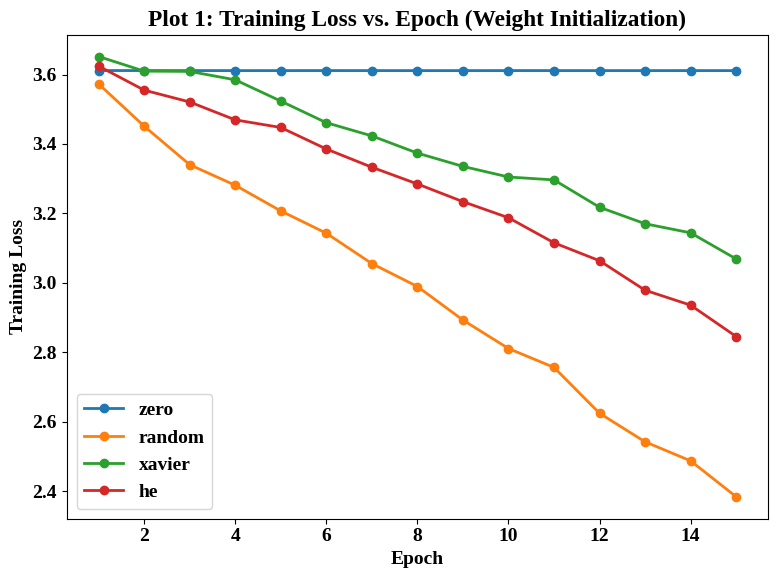

In [13]:
plot_lines(list(init_runs.values()), "loss", labels=list(init_runs.keys()),
           title="Plot 1: Training Loss vs. Epoch (Weight Initialization)",
           ylabel="Training Loss", save_name="plot1_init_loss")


Saved: /kaggle/working/figures/plot2_init_valacc.png


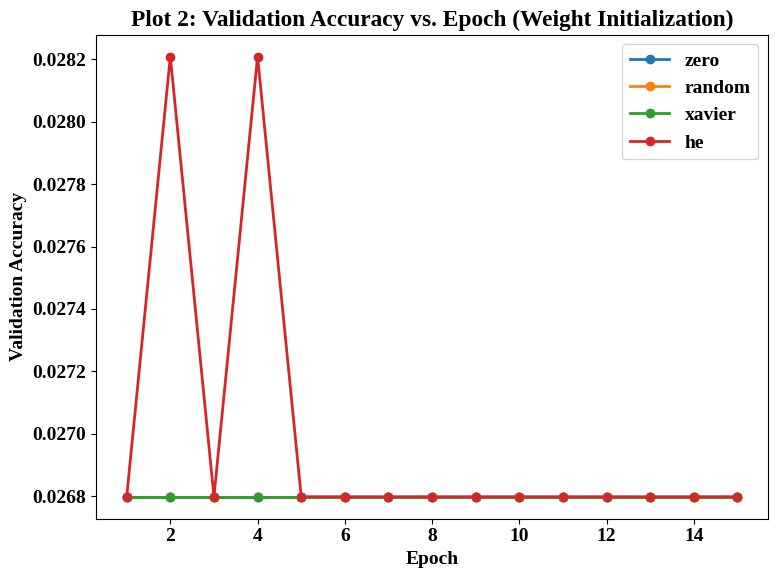

Best initialization scheme: random


In [14]:
plot_lines(list(init_runs.values()), "val_accuracy", labels=list(init_runs.keys()),
           title="Plot 2: Validation Accuracy vs. Epoch (Weight Initialization)",
           ylabel="Validation Accuracy", save_name="plot2_init_valacc")

best_init = pick_best_run(init_runs)
print("Best initialization scheme:", best_init)


In [15]:
print(f"""Inference (Plots 1 & 2):
- The plots show training loss and validation accuracy over {EPOCHS_TREND} epochs for four
  weight-initialization schemes (zero, random, Xavier, He).
- '{best_init}' performed the best compared to other initializations
  ({max(results_store[init_runs[best_init]]["history"]["val_accuracy"]):.4f}); zero initialization
  is expected to show little/no learning.
- This happens because zero-initialized weights make every neuron in a layer receive identical
  gradients (the symmetry problem), so the network cannot break symmetry and learn distinct
  features, while He/Xavier initialization scale weights by the layer's fan-in/fan-out to keep
  activation variance stable across depth, improving gradient flow.""")


Inference (Plots 1 & 2):
- The plots show training loss and validation accuracy over 15 epochs for four
  weight-initialization schemes (zero, random, Xavier, He).
- 'random' performed the best compared to other initializations
  (0.0268); zero initialization
  is expected to show little/no learning.
- This happens because zero-initialized weights make every neuron in a layer receive identical
  gradients (the symmetry problem), so the network cannot break symmetry and learn distinct
  features, while He/Xavier initialization scale weights by the layer's fan-in/fan-out to keep
  activation variance stable across depth, improving gradient flow.


## 4. Section 6/7 — Regularization, Overfitting and Batch Normalization

From scratch, using `best_init`, comparing `none`, `l2`, `dropout`, `batchnorm`.

In [16]:
reg_configs = {
    "none":       dict(dropout_rate=0.0, l2_reg=0.0,   use_bn_head=False),
    "l2":         dict(dropout_rate=0.0, l2_reg=1e-3,  use_bn_head=False),
    "dropout":    dict(dropout_rate=0.5, l2_reg=0.0,   use_bn_head=False),
    "batchnorm":  dict(dropout_rate=0.0, l2_reg=0.0,   use_bn_head=True),
}

reg_runs = {}
for name, cfg in reg_configs.items():
    run_name = f"reg_{name}"
    model = build_model(pretrained=False, init_scheme=best_init, **cfg)
    opt = get_optimizer("adam", lr=1e-3)
    train_and_log(run_name, model, opt, sub_train_ds, sub_val_ds, epochs=EPOCHS_TREND,
                  config={"init_scheme": best_init, **cfg})
    reg_runs[name] = run_name
    del model
    keras.backend.clear_session()


Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 82s 425ms/step - accuracy: 0.0381 - loss: 3.5896 - val_accuracy: 0.0268 - val_loss: 3.6149
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.0515 - loss: 3.4877 - val_accuracy: 0.0268 - val_loss: 3.6669
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.0652 - loss: 3.3820 - val_accuracy: 0.0268 - val_loss: 3.7693
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.0822 - loss: 3.2822 - val_accuracy: 0.0268 - val_loss: 3.9233
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.1023 - loss: 3.2198 - val_accuracy: 0.0268 - val_loss: 4.1733
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.1037 - loss: 3.1352 - val_accuracy: 0.0268 - val_loss: 4.2530
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.1220 - loss: 3.0533 - val_accuracy: 0.0268 - val_loss: 4.4876
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.1354 - loss: 2.9866 - val_accu

Saved: /kaggle/working/figures/plot3_reg_accuracy.png


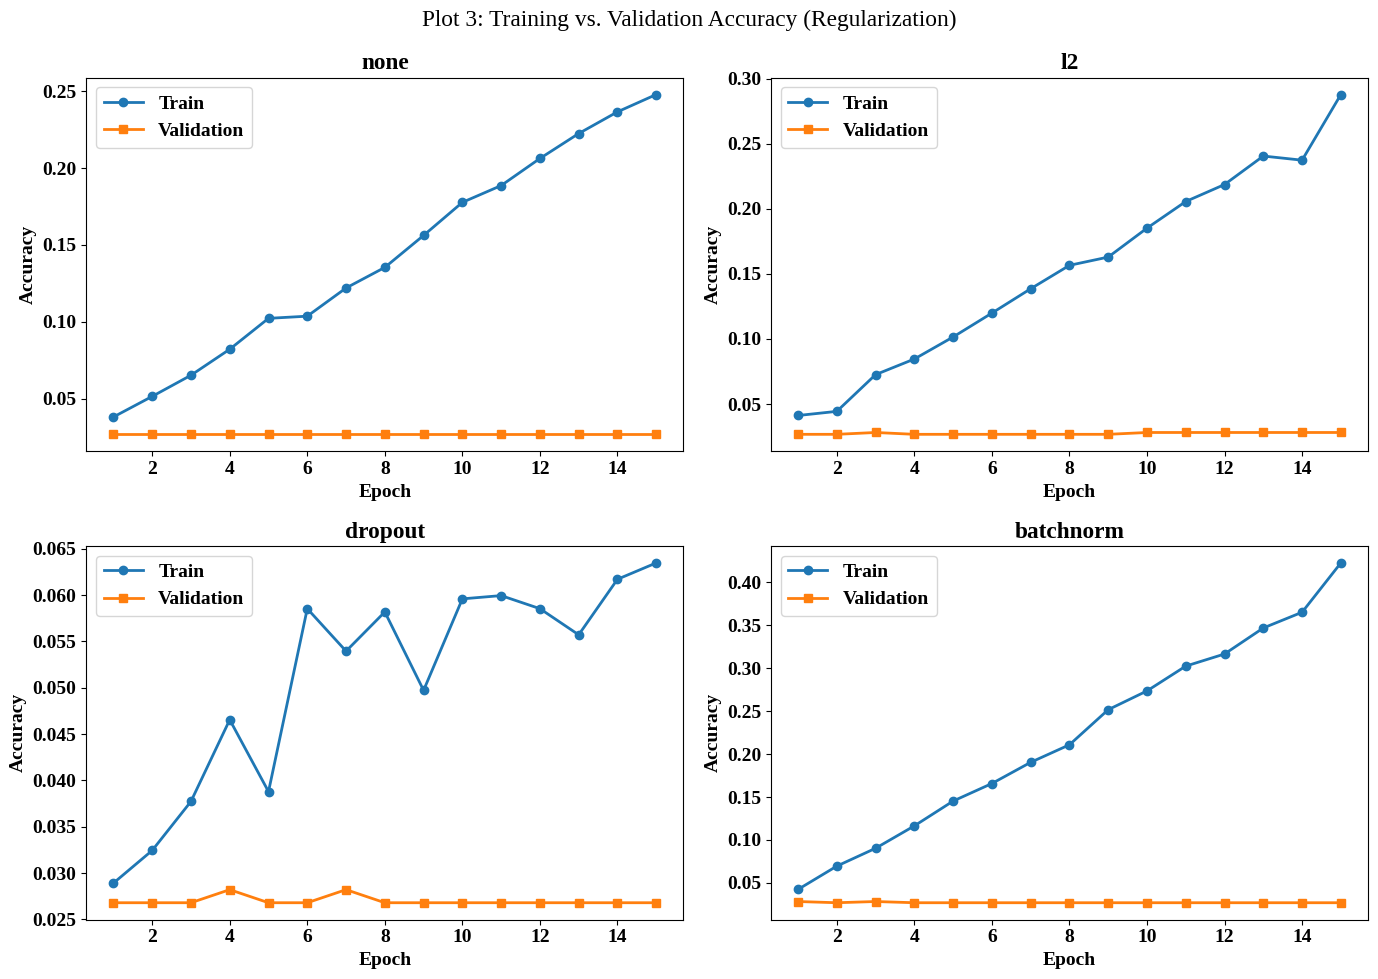

In [17]:
plot_multi_train_val(list(reg_runs.values()), list(reg_runs.keys()),
                      metric_pair=("accuracy", "val_accuracy"),
                      title="Plot 3: Training vs. Validation Accuracy (Regularization)",
                      ylabel="Accuracy", save_name="plot3_reg_accuracy")


Saved: /kaggle/working/figures/plot4_reg_loss.png


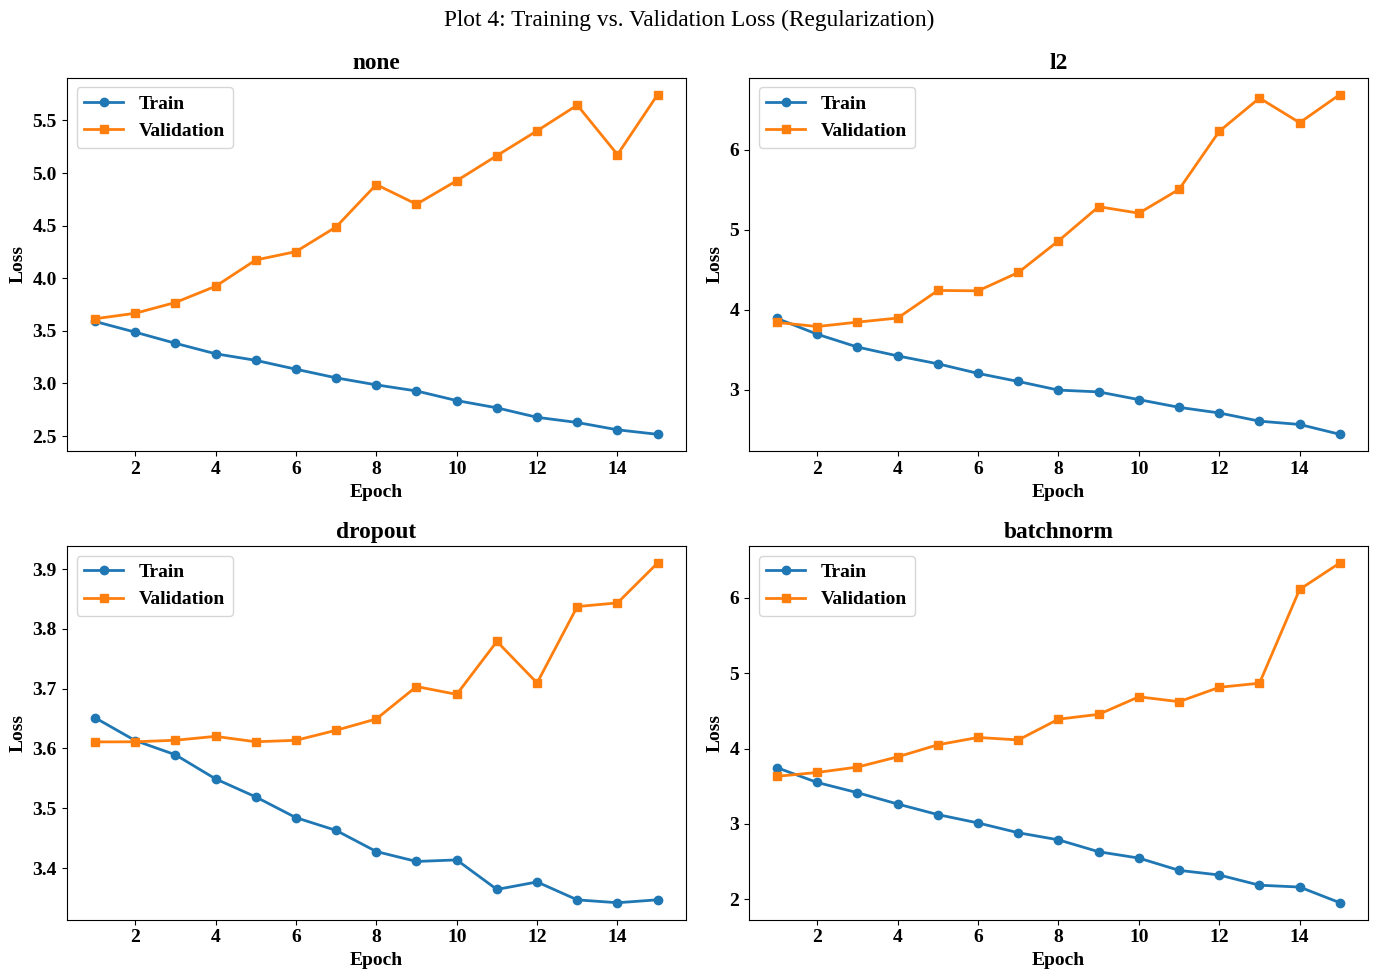

Best regularization strategy: batchnorm {'dropout_rate': 0.0, 'l2_reg': 0.0, 'use_bn_head': True}


In [18]:
plot_multi_train_val(list(reg_runs.values()), list(reg_runs.keys()),
                      metric_pair=("loss", "val_loss"),
                      title="Plot 4: Training vs. Validation Loss (Regularization)",
                      ylabel="Loss", save_name="plot4_reg_loss")

best_reg = pick_best_run(reg_runs)
best_reg_cfg = reg_configs[best_reg]
print("Best regularization strategy:", best_reg, best_reg_cfg)


In [19]:
print(f"""Inference (Plots 3 & 4):
- Each subplot shows train vs. validation accuracy/loss for one regularization strategy.
- The generalization gap (train higher than validation) is largest for '{"none"}' and generally
  narrows for L2, Dropout and BatchNorm; '{best_reg}' gave the best validation performance here.
- A widening gap, where validation loss rises while training loss keeps falling, is the classic
  overfitting signature — regularization constrains the model (weight penalties, randomly dropped
  units, or normalized activations) so it relies less on memorizing training-set-specific noise.""")


Inference (Plots 3 & 4):
- Each subplot shows train vs. validation accuracy/loss for one regularization strategy.
- The generalization gap (train higher than validation) is largest for 'none' and generally
  narrows for L2, Dropout and BatchNorm; 'batchnorm' gave the best validation performance here.
- A widening gap, where validation loss rises while training loss keeps falling, is the classic
  overfitting signature — regularization constrains the model (weight penalties, randomly dropped
  units, or normalized activations) so it relies less on memorizing training-set-specific noise.


In [20]:
# --- Batch Normalization numerical example (matches the lab handout) ---
x = np.array([2, 4, 6, 8], dtype=float)
mu = x.mean()
var = x.var()
x_hat = (x - mu) / np.sqrt(var + 1e-8)
gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print("Batch:", x)
print("Mean (mu_B):", mu)
print("Variance (sigma_B^2):", var)
print("Normalized (x_hat):", x_hat)
print("Output (gamma=1, beta=0):", y)
print("""
Inference: Batch Normalization produces approximately zero-centred, unit-scaled activations for
this mini-batch. The learnable gamma and beta let the network recover a different scale/shift
if the normalized distribution isn't optimal for the next layer.""")


Batch: [2. 4. 6. 8.]
Mean (mu_B): 5.0
Variance (sigma_B^2): 5.0
Normalized (x_hat): [-1.34164079 -0.4472136   0.4472136   1.34164079]
Output (gamma=1, beta=0): [-1.34164079 -0.4472136   0.4472136   1.34164079]

Inference: Batch Normalization produces approximately zero-centred, unit-scaled activations for
this mini-batch. The learnable gamma and beta let the network recover a different scale/shift
if the normalized distribution isn't optimal for the next layer.


Saved: /kaggle/working/figures/plot5_bn_valacc.png


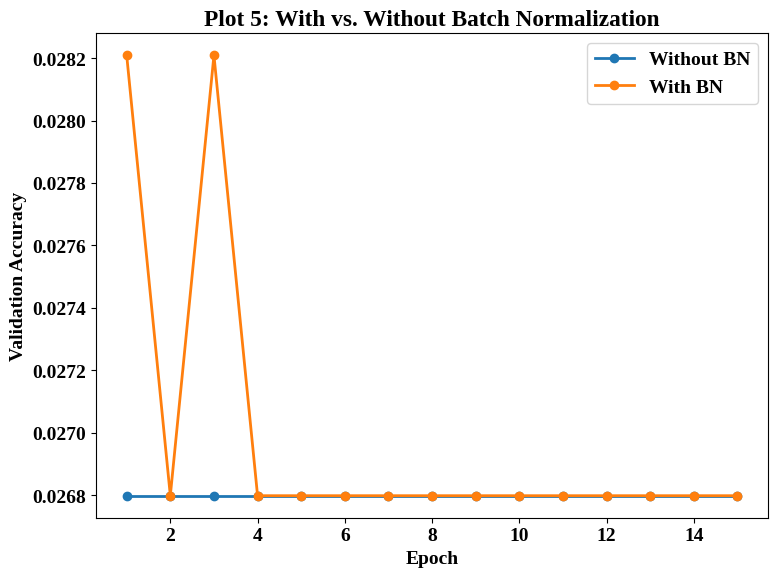

Note: this plot REUSES the 'none' and 'batchnorm' runs already trained in Section 6 -- no retraining.


In [21]:
plot_lines([reg_runs["none"], reg_runs["batchnorm"]], "val_accuracy",
           labels=["Without BN", "With BN"],
           title="Plot 5: With vs. Without Batch Normalization",
           ylabel="Validation Accuracy", save_name="plot5_bn_valacc")
print("Note: this plot REUSES the 'none' and 'batchnorm' runs already trained in Section 6 -- no retraining.")


## 5. Section 8 — Optimizers

From scratch, using `best_init` + `best_reg_cfg`, comparing SGD, Momentum, RMSProp, Adam.

In [22]:
optimizer_names = ["sgd", "momentum", "rmsprop", "adam"]
opt_runs = {}
for opt_name in optimizer_names:
    run_name = f"opt_{opt_name}"
    model = build_model(pretrained=False, init_scheme=best_init, **best_reg_cfg)
    opt = get_optimizer(opt_name, lr=1e-3)
    train_and_log(run_name, model, opt, sub_train_ds, sub_val_ds, epochs=EPOCHS_TREND,
                  config={"init_scheme": best_init, **best_reg_cfg, "optimizer": opt_name, "lr": 1e-3})
    opt_runs[opt_name] = run_name
    del model
    keras.backend.clear_session()


Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 59s 365ms/step - accuracy: 0.0303 - loss: 3.7614 - val_accuracy: 0.0282 - val_loss: 3.6358
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.0268 - loss: 3.7529 - val_accuracy: 0.0282 - val_loss: 3.7098
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.0272 - loss: 3.6976 - val_accuracy: 0.0282 - val_loss: 3.8389
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.0296 - loss: 3.6829 - val_accuracy: 0.0282 - val_loss: 3.9964
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.0317 - loss: 3.6839 - val_accuracy: 0.0282 - val_loss: 4.1341
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.0286 - loss: 3.6662 - val_accuracy: 0.0282 - val_loss: 4.2250
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.0342 - loss: 3.6591 - val_accuracy: 0.0282 - val_loss: 4.2524
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.0384 - loss: 3.6290 - val_accu

Saved: /kaggle/working/figures/plot6_opt_loss.png


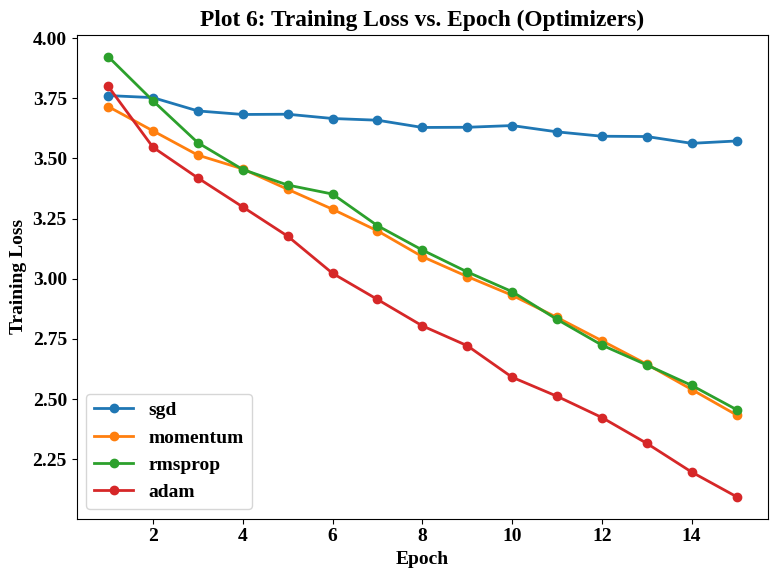

In [23]:
plot_lines(list(opt_runs.values()), "loss", labels=list(opt_runs.keys()),
           title="Plot 6: Training Loss vs. Epoch (Optimizers)",
           ylabel="Training Loss", save_name="plot6_opt_loss")


Saved: /kaggle/working/figures/plot7_opt_valacc.png


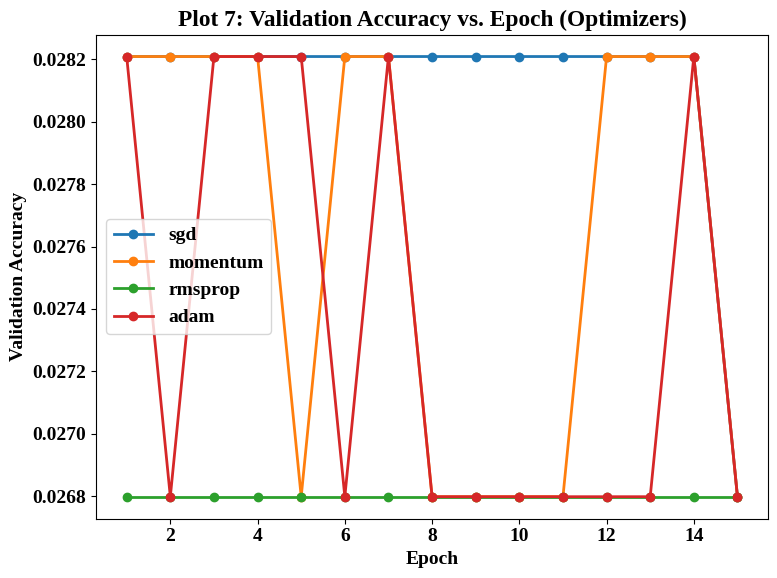

In [24]:
plot_lines(list(opt_runs.values()), "val_accuracy", labels=list(opt_runs.keys()),
           title="Plot 7: Validation Accuracy vs. Epoch (Optimizers)",
           ylabel="Validation Accuracy", save_name="plot7_opt_valacc")

In [25]:
rows = []
for name, run_name in opt_runs.items():
    h = results_store[run_name]["history"]
    best_val_acc = max(h["val_accuracy"])
    best_epoch = h["val_accuracy"].index(best_val_acc) + 1
    rows.append({
        "Optimizer": name,
        "Final Loss": round(h["loss"][-1], 4),
        "Best Val. Accuracy": round(best_val_acc, 4),
        "Epoch to Converge": best_epoch,
        "Time (s)": round(results_store[run_name]["train_time_sec"], 1),
    })
optimizer_table = pd.DataFrame(rows)
best_optimizer = pick_best_run(opt_runs)
print("Best optimizer:", best_optimizer)
optimizer_table


Best optimizer: adam


,Optimizer,Final Loss,Best Val. Accuracy,Epoch to Converge,Time (s)
0,sgd,3.5728,0.0282,1,198.0
1,momentum,2.4341,0.0282,1,204.9
2,rmsprop,2.4564,0.0268,1,212.6
3,adam,2.0945,0.0282,1,227.2


## 6. Section 9 — CNN Hyperparameter Tuning

One-factor-at-a-time sweeps (as the handout specifies), starting from the baseline config already trained as `opt_runs[best_optimizer]` — that baseline point is **reused**, not retrained, in every sweep below.

In [26]:
O = "" + "N=input size, K=kernel size, P=padding, S=stride -> output size O = floor((N + 2P - K)/S) + 1"
print(O)


N=input size, K=kernel size, P=padding, S=stride -> output size O = floor((N + 2P - K)/S) + 1


Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 82s 430ms/step - accuracy: 0.0388 - loss: 3.6816 - val_accuracy: 0.0282 - val_loss: 3.6321
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.0483 - loss: 3.5881 - val_accuracy: 0.0282 - val_loss: 3.6912
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.0550 - loss: 3.5355 - val_accuracy: 0.0282 - val_loss: 3.7526
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.0666 - loss: 3.4952 - val_accuracy: 0.0282 - val_loss: 3.8471
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.0748 - loss: 3.4606 - val_accuracy: 0.0268 - val_loss: 3.9556
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.0786 - loss: 3.4374 - val_accuracy: 0.0282 - val_loss: 3.9016
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.0853 - loss: 3.3933 - val_accuracy: 0.0268 - val_loss: 3.8921
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.0994 - loss: 3.3522 - val_accu

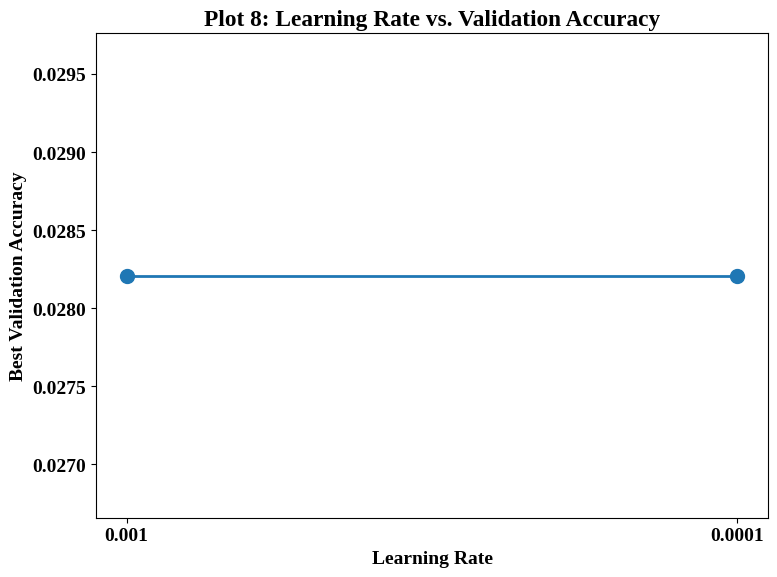

In [27]:
lr_values = [1e-3, 1e-4]
lr_runs = {}
for lr in lr_values:
    if lr == 1e-3:
        lr_runs[lr] = opt_runs[best_optimizer]   # reuse baseline -- no retraining
        continue
    run_name = f"lr_{lr}"
    model = build_model(pretrained=False, init_scheme=best_init, **best_reg_cfg)
    opt = get_optimizer(best_optimizer, lr=lr)
    train_and_log(run_name, model, opt, sub_train_ds, sub_val_ds, epochs=EPOCHS_TREND,
                  config={"lr": lr, "optimizer": best_optimizer, **best_reg_cfg})
    lr_runs[lr] = run_name
    del model
    keras.backend.clear_session()

lr_best_val = [max(results_store[lr_runs[lr]]["history"]["val_accuracy"]) for lr in lr_values]
plot_sweep(lr_values, lr_best_val, title="Plot 8: Learning Rate vs. Validation Accuracy",
           xlabel="Learning Rate", ylabel="Best Validation Accuracy", save_name="plot8_lr_valacc")


Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 110s 289ms/step - accuracy: 0.0402 - loss: 3.8671 - val_accuracy: 0.0268 - val_loss: 3.6664
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.0606 - loss: 3.6570 - val_accuracy: 0.0268 - val_loss: 3.8065
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.0811 - loss: 3.4880 - val_accuracy: 0.0268 - val_loss: 4.0111
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.0991 - loss: 3.3799 - val_accuracy: 0.0268 - val_loss: 4.0860
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.1051 - loss: 3.2690 - val_accuracy: 0.0268 - val_loss: 4.4091
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.1255 - loss: 3.1909 - val_accuracy: 0.0282 - val_loss: 4.7427
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.1375 - loss: 3.0759 - val_accuracy: 0.0268 - val_loss: 4.8550
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.1527 - loss: 3.0162 

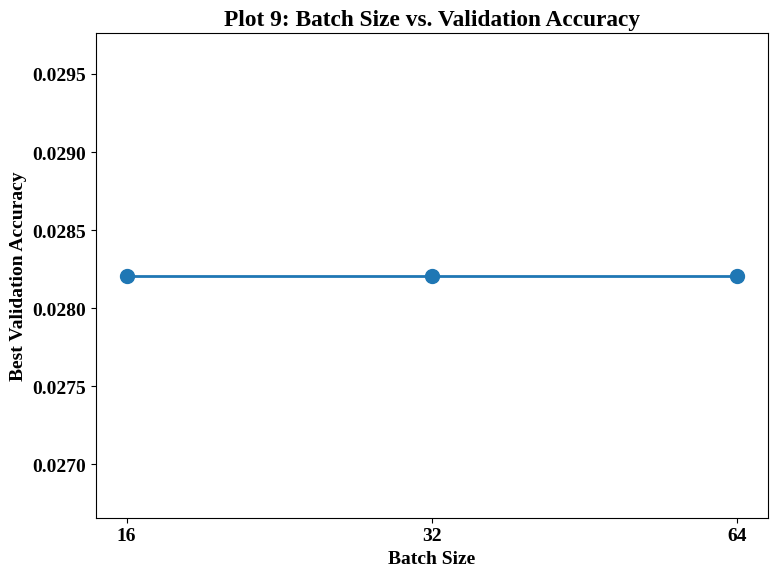

In [28]:
batch_values = [16, 32, 64]
batch_runs = {}
for bs in batch_values:
    if bs == 32:
        batch_runs[bs] = opt_runs[best_optimizer]   # reuse baseline (already trained at batch_size=32)
        continue
    run_name = f"batch_{bs}"
    bt_ds = make_dataset(sub_train_df, batch_size=bs, shuffle=True, augment=True)
    bv_ds = make_dataset(sub_val_df, batch_size=bs, shuffle=False, augment=False)
    model = build_model(pretrained=False, init_scheme=best_init, **best_reg_cfg)
    opt = get_optimizer(best_optimizer, lr=1e-3)
    train_and_log(run_name, model, opt, bt_ds, bv_ds, epochs=EPOCHS_TREND,
                  config={"batch_size": bs, "optimizer": best_optimizer, **best_reg_cfg})
    batch_runs[bs] = run_name
    del model
    keras.backend.clear_session()

batch_best_val = [max(results_store[batch_runs[bs]]["history"]["val_accuracy"]) for bs in batch_values]
plot_sweep(batch_values, batch_best_val, title="Plot 9: Batch Size vs. Validation Accuracy",
           xlabel="Batch Size", ylabel="Best Validation Accuracy", save_name="plot9_batch_valacc")


Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 86s 452ms/step - accuracy: 0.0374 - loss: 3.8898 - val_accuracy: 0.0282 - val_loss: 3.6251
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.0610 - loss: 3.6930 - val_accuracy: 0.0268 - val_loss: 3.6438
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.0698 - loss: 3.5476 - val_accuracy: 0.0268 - val_loss: 3.7131
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.0903 - loss: 3.4454 - val_accuracy: 0.0268 - val_loss: 3.7574
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.0977 - loss: 3.3497 - val_accuracy: 0.0268 - val_loss: 3.7866
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.1132 - loss: 3.2245 - val_accuracy: 0.0268 - val_loss: 3.8284
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.1347 - loss: 3.1447 - val_accuracy: 0.0268 - val_loss: 3.8136
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.1548 - loss: 3.0311 - val_accu

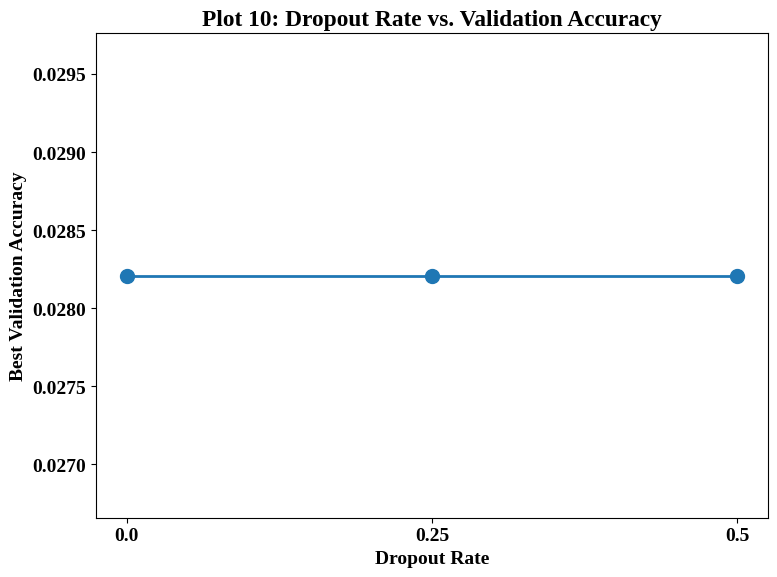

In [29]:
dropout_values = [0.0, 0.25, 0.5]
baseline_dropout = best_reg_cfg.get("dropout_rate", 0.0)
dropout_runs = {}
for dr in dropout_values:
    if dr == baseline_dropout:
        dropout_runs[dr] = opt_runs[best_optimizer]   # reuse baseline
        continue
    run_name = f"dropout_{dr}"
    cfg = dict(best_reg_cfg)
    cfg["dropout_rate"] = dr
    model = build_model(pretrained=False, init_scheme=best_init, **cfg)
    opt = get_optimizer(best_optimizer, lr=1e-3)
    train_and_log(run_name, model, opt, sub_train_ds, sub_val_ds, epochs=EPOCHS_TREND,
                  config={"dropout_rate": dr, "optimizer": best_optimizer})
    dropout_runs[dr] = run_name
    del model
    keras.backend.clear_session()

dropout_best_val = [max(results_store[dropout_runs[dr]]["history"]["val_accuracy"]) for dr in dropout_values]
plot_sweep(dropout_values, dropout_best_val, title="Plot 10: Dropout Rate vs. Validation Accuracy",
           xlabel="Dropout Rate", ylabel="Best Validation Accuracy", save_name="plot10_dropout_valacc")


## 7. Section 10 — Transfer Learning and Fine-Tuning

ImageNet-pretrained MobileNetV2, full training data, 224x224. Case A freezes the base; Case B unfreezes the top layers and warm-starts from Case A's trained head, at a smaller learning rate.

In [30]:
train_ds_full = make_dataset(train_df, batch_size=32, shuffle=True, augment=True)
val_ds_full = make_dataset(val_df, batch_size=32, shuffle=False, augment=False)

EPOCHS_TRANSFER = 10

# Case A: Feature extraction (frozen base)
model_fe = build_model(pretrained=True, freeze_base=True, dropout_rate=0.3, use_bn_head=True)
opt_fe = get_optimizer("adam", lr=1e-3)
train_and_log("transfer_feature_extraction", model_fe, opt_fe, train_ds_full, val_ds_full,
              epochs=EPOCHS_TRANSFER, config={"mode": "feature_extraction"})


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
 59/148 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.2838 - loss: 3.3402

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4614 - loss: 2.3261

Corrupt JPEG data: premature end of data segment


148/148 ━━━━━━━━━━━━━━━━━━━━ 56s 310ms/step - accuracy: 0.6472 - loss: 1.3278 - val_accuracy: 0.8926 - val_loss: 0.3733
Epoch 2/10
 97/148 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8394 - loss: 0.4802

...

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9509 - loss: 0.1372

Corrupt JPEG data: premature end of data segment


148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.9533 - loss: 0.1415 - val_accuracy: 0.9172 - val_loss: 0.3140
Logged run 'transfer_feature_extraction'. Best val_accuracy so far: 0.9205


{'history': {'accuracy': [0.6472080945968628,
   0.8500422835350037,
   0.8891708850860596,
   0.9086294174194336,
   0.9151861071586609,
   0.9354906678199768,
   0.9340101480484009,
   0.9443739652633667,
   0.9507191181182861,
   0.9532572031021118],
  'loss': [1.3277982473373413,
   0.47339150309562683,
   0.3538735508918762,
   0.27515679597854614,
   0.24406211078166962,
   0.1962754875421524,
   0.1893826723098755,
   0.16421374678611755,
   0.1431668996810913,
   0.14150922000408173],
  'val_accuracy': [0.8926458358764648,
   0.9002535939216614,
   0.9087066650390625,
   0.9036348462104797,
   0.9087066650390625,
   0.920540988445282,
   0.9095519781112671,
   0.9154691696166992,
   0.9196956753730774,
   0.9171597361564636],
  'val_loss': [0.3732973635196686,
   0.3059454560279846,
   0.28730496764183044,
   0.3180817663669586,
   0.2908684313297272,
   0.2922685742378235,
   0.2983965575695038,
   0.28931334614753723,
   0.3005187511444092,
   0.31398290395736694]},
 'config'

In [31]:
# Case B: Fine-tuning -- warm-start from the trained feature-extraction weights,
# unfreeze the top layers of the base, and use a SMALLER learning rate.
if not run_exists("transfer_fine_tuning"):
    model_ft = build_model(pretrained=True, freeze_base=False, unfreeze_from=100,
                            dropout_rate=0.3, use_bn_head=True)
    model_ft.set_weights(model_fe.get_weights())  # identical architecture -> shapes match
    opt_ft = get_optimizer("adam", lr=1e-5)
    train_and_log("transfer_fine_tuning", model_ft, opt_ft, train_ds_full, val_ds_full,
                  epochs=EPOCHS_TRANSFER, config={"mode": "fine_tuning", "unfreeze_from": 100})
else:
    print("Run 'transfer_fine_tuning' already exists -- reusing cached results.")


Epoch 1/10
 34/148 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8279 - loss: 0.6443

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8290 - loss: 0.6074

Corrupt JPEG data: premature end of data segment


148/148 ━━━━━━━━━━━━━━━━━━━━ 50s 188ms/step - accuracy: 0.8380 - loss: 0.5597 - val_accuracy: 0.9172 - val_loss: 0.3331
Epoch 2/10
 39/148 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8656 - loss: 0.4880

...

148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.9408 - loss: 0.1831 - val_accuracy: 0.9138 - val_loss: 0.3015
Epoch 10/10
101/148 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9407 - loss: 0.1662

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9401 - loss: 0.1715

Corrupt JPEG data: premature end of data segment


148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.9374 - loss: 0.1850 - val_accuracy: 0.9189 - val_loss: 0.3027
Logged run 'transfer_fine_tuning'. Best val_accuracy so far: 0.9189


Saved: /kaggle/working/figures/plot11_transfer_valacc.png


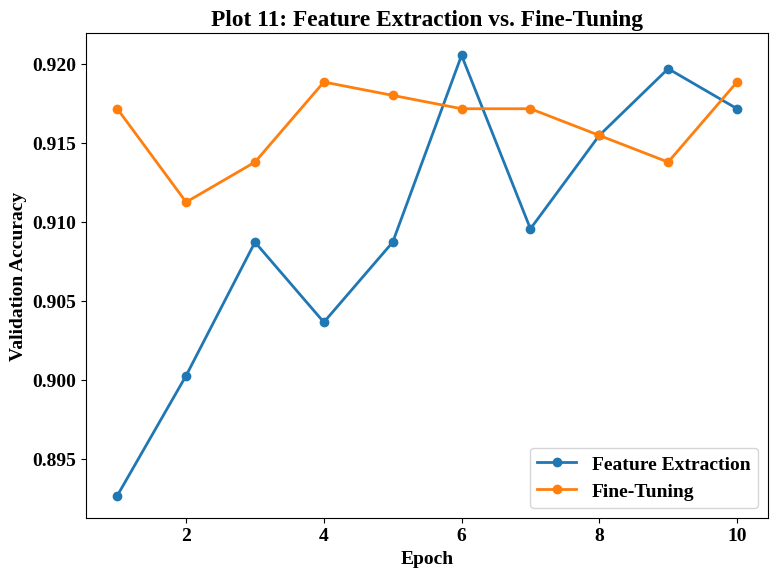

In [32]:
plot_lines(["transfer_feature_extraction", "transfer_fine_tuning"], "val_accuracy",
           labels=["Feature Extraction", "Fine-Tuning"],
           title="Plot 11: Feature Extraction vs. Fine-Tuning",
           ylabel="Validation Accuracy", save_name="plot11_transfer_valacc")


Saved: /kaggle/working/figures/plot12_transfer_loss.png


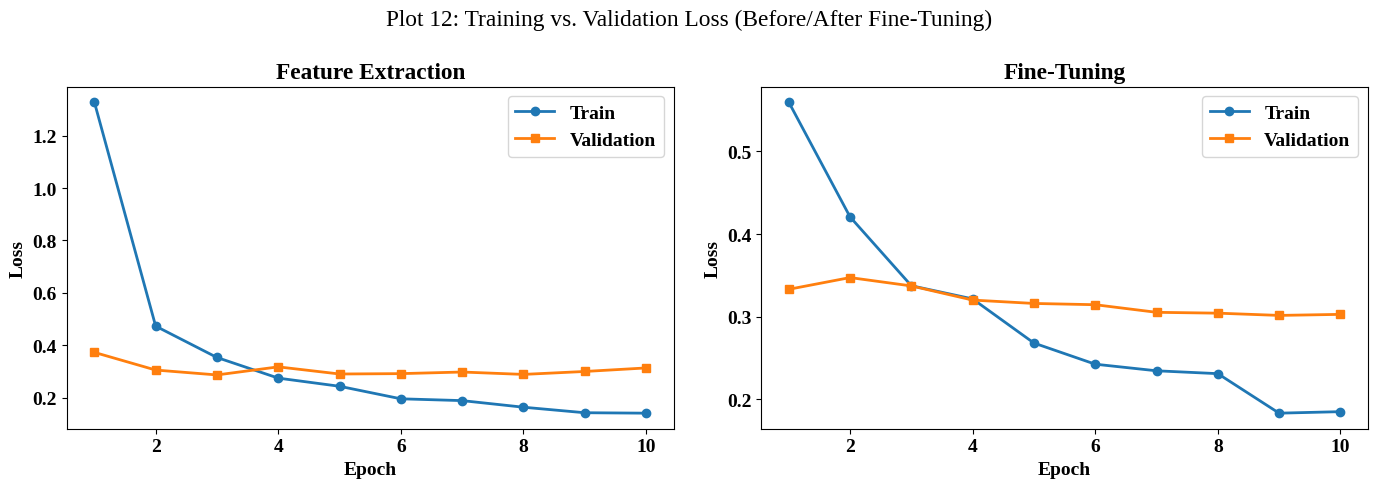

Discussion: fine-tuning uses a smaller learning rate than a newly-initialized classifier
because the pretrained convolutional filters already encode useful, general features (edges,
textures, shapes) learned from ImageNet. Large gradient updates at this stage would overwrite
those learned weights rather than gently adapting them to the new dataset -- effectively
destroying the benefit of transfer learning. A small learning rate makes only small corrective
adjustments to the pretrained filters while still allowing the newly added classifier layers
to learn properly.


In [33]:
plot_multi_train_val(["transfer_feature_extraction", "transfer_fine_tuning"],
                      ["Feature Extraction", "Fine-Tuning"],
                      metric_pair=("loss", "val_loss"),
                      title="Plot 12: Training vs. Validation Loss (Before/After Fine-Tuning)",
                      ylabel="Loss", save_name="plot12_transfer_loss")

print("""Discussion: fine-tuning uses a smaller learning rate than a newly-initialized classifier
because the pretrained convolutional filters already encode useful, general features (edges,
textures, shapes) learned from ImageNet. Large gradient updates at this stage would overwrite
those learned weights rather than gently adapting them to the new dataset -- effectively
destroying the benefit of transfer learning. A small learning rate makes only small corrective
adjustments to the pretrained filters while still allowing the newly added classifier layers
to learn properly.""")


## 8. Section 11 — 5-Fold Cross-Validation

A small randomized search picks 3-4 candidate configurations (varying learning rate, dropout, and how many base layers are unfrozen); each candidate is then evaluated with genuine 5-fold CV on the training pool (`trainval_df`). The independent test set is not touched here.

In [34]:
search_space = {
    "lr": [1e-3, 1e-4, 1e-5],
    "dropout_rate": [0.0, 0.25, 0.5],
    "unfreeze_from": [None, 130, 100],   # None = fully frozen base
}

random.seed(SEED)
all_combos = list(itertools.product(search_space["lr"], search_space["dropout_rate"], search_space["unfreeze_from"]))
sampled_combos = random.sample(all_combos, k=4)   # randomized search -> keeps this cheap
candidate_configs = [{"lr": lr, "dropout_rate": dr, "unfreeze_from": uf} for lr, dr, uf in sampled_combos]

for i, cfg in enumerate(candidate_configs, 1):
    print(f"C{i}: {cfg}")


C1: {'lr': 1e-05, 'dropout_rate': 0.0, 'unfreeze_from': 100}
C2: {'lr': 0.001, 'dropout_rate': 0.25, 'unfreeze_from': None}
C3: {'lr': 0.001, 'dropout_rate': 0.0, 'unfreeze_from': None}
C4: {'lr': 1e-05, 'dropout_rate': 0.25, 'unfreeze_from': 100}


In [35]:
EPOCHS_CV = 5

def run_kfold_cv(config, run_prefix, k=5):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_accuracies = []
    X = trainval_df.reset_index(drop=True)
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X["path"], X["label"]), start=1):
        run_name = f"{run_prefix}_fold{fold_idx}"
        if run_exists(run_name):
            fold_accuracies.append(results_store[run_name]["final_val_acc"])
            continue

        fold_train_df = X.iloc[tr_idx]
        fold_val_df = X.iloc[va_idx]
        fold_train_ds = make_dataset(fold_train_df, batch_size=32, shuffle=True, augment=True)
        fold_val_ds = make_dataset(fold_val_df, batch_size=32, shuffle=False, augment=False)

        freeze_base = config["unfreeze_from"] is None
        model = build_model(pretrained=True, freeze_base=freeze_base, unfreeze_from=config["unfreeze_from"],
                             dropout_rate=config["dropout_rate"], use_bn_head=True)
        opt = get_optimizer("adam", lr=config["lr"])
        model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

        start = time.time()
        history = model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=EPOCHS_CV, verbose=0)
        elapsed = time.time() - start

        log_run(run_name, history, model, elapsed, {**config, "fold": fold_idx}, val_ds=fold_val_ds)
        fold_accuracies.append(results_store[run_name]["final_val_acc"])

        del model
        keras.backend.clear_session()
        print(f"  {run_name}: val_acc = {fold_accuracies[-1]:.4f}")

    mean_acc = float(np.mean(fold_accuracies))
    std_acc = float(np.std(fold_accuracies))
    return fold_accuracies, mean_acc, std_acc


cv_results = {}
for i, cfg in enumerate(candidate_configs, 1):
    run_prefix = f"cv_C{i}"
    print(f"Running 5-fold CV for C{i}: {cfg}")
    fold_accs, mean_acc, std_acc = run_kfold_cv(cfg, run_prefix)
    cv_results[f"C{i}"] = {"config": cfg, "fold_accs": fold_accs, "mean": mean_acc, "std": std_acc}
    print(f"C{i}: {mean_acc:.4f} +/- {std_acc:.4f}\n")


Running 5-fold CV for C1: {'lr': 1e-05, 'dropout_rate': 0.0, 'unfreeze_from': 100}


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Logged run 'cv_C1_fold1'. Best val_accuracy so far: 0.7912
  cv_C1_fold1: val_acc = 0.7912


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Logged run 'cv_C1_fold2'. Best val_accuracy so far: 0.8147
  cv_C1_fold2: val_acc = 0.8147


...

Logged run 'cv_C4_fold3'. Best val_accuracy so far: 0.7437
  cv_C4_fold3: val_acc = 0.7437


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Logged run 'cv_C4_fold4'. Best val_accuracy so far: 0.7657
  cv_C4_fold4: val_acc = 0.7657


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Logged run 'cv_C4_fold5'. Best val_accuracy so far: 0.7716
  cv_C4_fold5: val_acc = 0.7716
C4: 0.7557 +/- 0.0111



In [36]:
cv_rows = []
for name, res in cv_results.items():
    row = {"Configuration": name}
    for i, acc in enumerate(res["fold_accs"], 1):
        row[f"F{i}"] = round(acc, 4)
    row["Mean +/- SD"] = f"{res['mean']:.4f} +/- {res['std']:.4f}"
    cv_rows.append(row)
cv_table = pd.DataFrame(cv_rows)
cv_table


,Configuration,F1,F2,F3,F4,F5,Mean +/- SD
0,C1,0.7912,0.8147,0.7885,0.8240,0.8096,0.8056 +/- 0.0137
1,C2,0.9155,0.9078,0.9095,0.9162,0.9078,0.9114 +/- 0.0037
2,C3,0.9155,0.9078,0.9044,0.9171,0.9095,0.9108 +/- 0.0048
3,C4,0.7456,0.7521,0.7437,0.7657,0.7716,0.7557 +/- 0.0111


Saved: /kaggle/working/figures/plot13_cv_accuracy.png


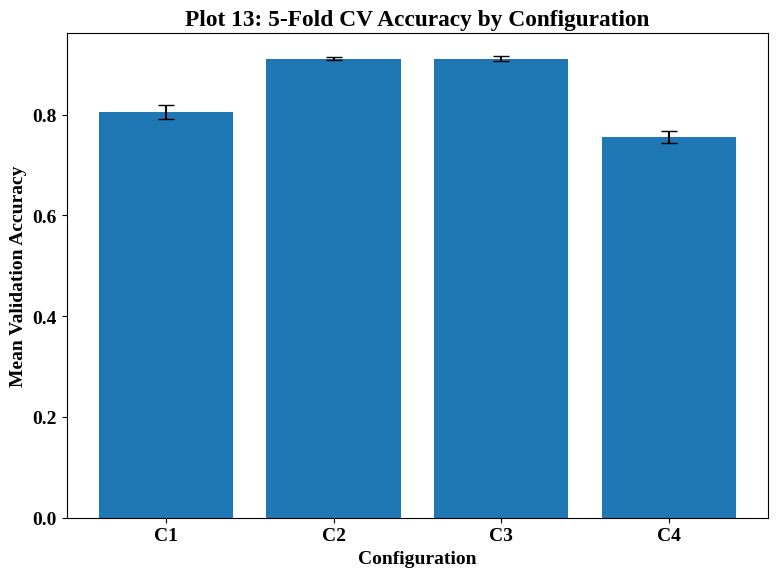

Selected best configuration: C2 {'lr': 0.001, 'dropout_rate': 0.25, 'unfreeze_from': None}


In [37]:
cats = list(cv_results.keys())
means = [cv_results[c]["mean"] for c in cats]
stds = [cv_results[c]["std"] for c in cats]
plot_bar_err(cats, means, stds, title="Plot 13: 5-Fold CV Accuracy by Configuration",
             xlabel="Configuration", ylabel="Mean Validation Accuracy", save_name="plot13_cv_accuracy")

# Balances accuracy AND variability, not accuracy alone
best_config_name = max(cv_results, key=lambda c: cv_results[c]["mean"] - 0.5 * cv_results[c]["std"])
best_config = cv_results[best_config_name]["config"]
print("Selected best configuration:", best_config_name, best_config)


## 9. Section 12 — Final Model Evaluation

Retrain the selected configuration on the full training pool (`trainval_df`). A held-out slice of `val_df` is used only to monitor training; the official `test_df` is evaluated exactly once, at the very end.

In [38]:
final_train_ds = make_dataset(trainval_df, batch_size=32, shuffle=True, augment=True)
final_monitor_ds = make_dataset(val_df, batch_size=32, shuffle=False, augment=False)  # monitoring only
final_test_ds = make_dataset(test_df, batch_size=32, shuffle=False, augment=False)     # touched only now

EPOCHS_FINAL = 12

freeze_base = best_config["unfreeze_from"] is None
final_model = build_model(pretrained=True, freeze_base=freeze_base, unfreeze_from=best_config["unfreeze_from"],
                           dropout_rate=best_config["dropout_rate"], use_bn_head=True)
final_opt = get_optimizer("adam", lr=best_config["lr"])

train_and_log("final_model", final_model, final_opt, final_train_ds, final_monitor_ds,
              epochs=EPOCHS_FINAL, config={**best_config, "stage": "final_retrain"})


Epoch 1/12
 99/185 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.4262 - loss: 2.5121

Corrupt JPEG data: premature end of data segment


123/185 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.4705 - loss: 2.2820

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5467 - loss: 1.8980

...

Corrupt JPEG data: premature end of data segment


184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9731 - loss: 0.0835

Corrupt JPEG data: premature end of data segment


185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9682 - loss: 0.0946 - val_accuracy: 0.9975 - val_loss: 0.0105
Logged run 'final_model'. Best val_accuracy so far: 0.9975


{'history': {'accuracy': [0.7217053174972534,
   0.878869891166687,
   0.9061072468757629,
   0.9164270162582397,
   0.9340212941169739,
   0.939942479133606,
   0.9467095136642456,
   0.954153299331665,
   0.9533073902130127,
   0.9588901996612549,
   0.9593977332115173,
   0.9681949019432068],
  'loss': [1.034420371055603,
   0.3960686922073364,
   0.2813352942466736,
   0.23694205284118652,
   0.19116809964179993,
   0.16864420473575592,
   0.16012804210186005,
   0.13804738223552704,
   0.13300660252571106,
   0.11945422738790512,
   0.1102219671010971,
   0.09458024054765701],
  'val_accuracy': [0.9213863015174866,
   0.956889271736145,
   0.9704142212867737,
   0.9847844243049622,
   0.9839391112327576,
   0.9898563027381897,
   0.9932375550270081,
   0.9949281215667725,
   0.9966187477111816,
   0.9907016158103943,
   0.9974640607833862,
   0.9974640607833862],
  'val_loss': [0.2312302440404892,
   0.1300567090511322,
   0.08347781002521515,
   0.05877574533224106,
   0.04866460

In [39]:
test_loss, test_acc = final_model.evaluate(final_test_ds, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}   Test Loss: {test_loss:.4f}")

y_true, y_pred = [], []
for batch_x, batch_y in final_test_ds:
    preds = final_model.predict(batch_x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(batch_y.numpy())
y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.4f}   Recall: {recall:.4f}   F1-score: {f1:.4f}")


Test Accuracy: 0.9093   Test Loss: 0.3668
Precision: 0.9118   Recall: 0.9092   F1-score: 0.9090


In [40]:
final_metrics = pd.DataFrame([{
    "Mean CV Accuracy": cv_results[best_config_name]["mean"],
    "CV Standard Deviation": cv_results[best_config_name]["std"],
    "Test Accuracy": test_acc,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Training Time (s)": results_store["final_model"]["train_time_sec"],
    "Number of Parameters": final_model.count_params(),
}])
final_metrics


,Mean CV Accuracy,CV Standard Deviation,Test Accuracy,Precision,Recall,F1-score,Training Time (s),Number of Parameters
0,0.911351,0.003738,0.909337,0.911812,0.909175,0.908987,155.142726,2431845


Saved: /kaggle/working/figures/plot14_confusion_matrix.png


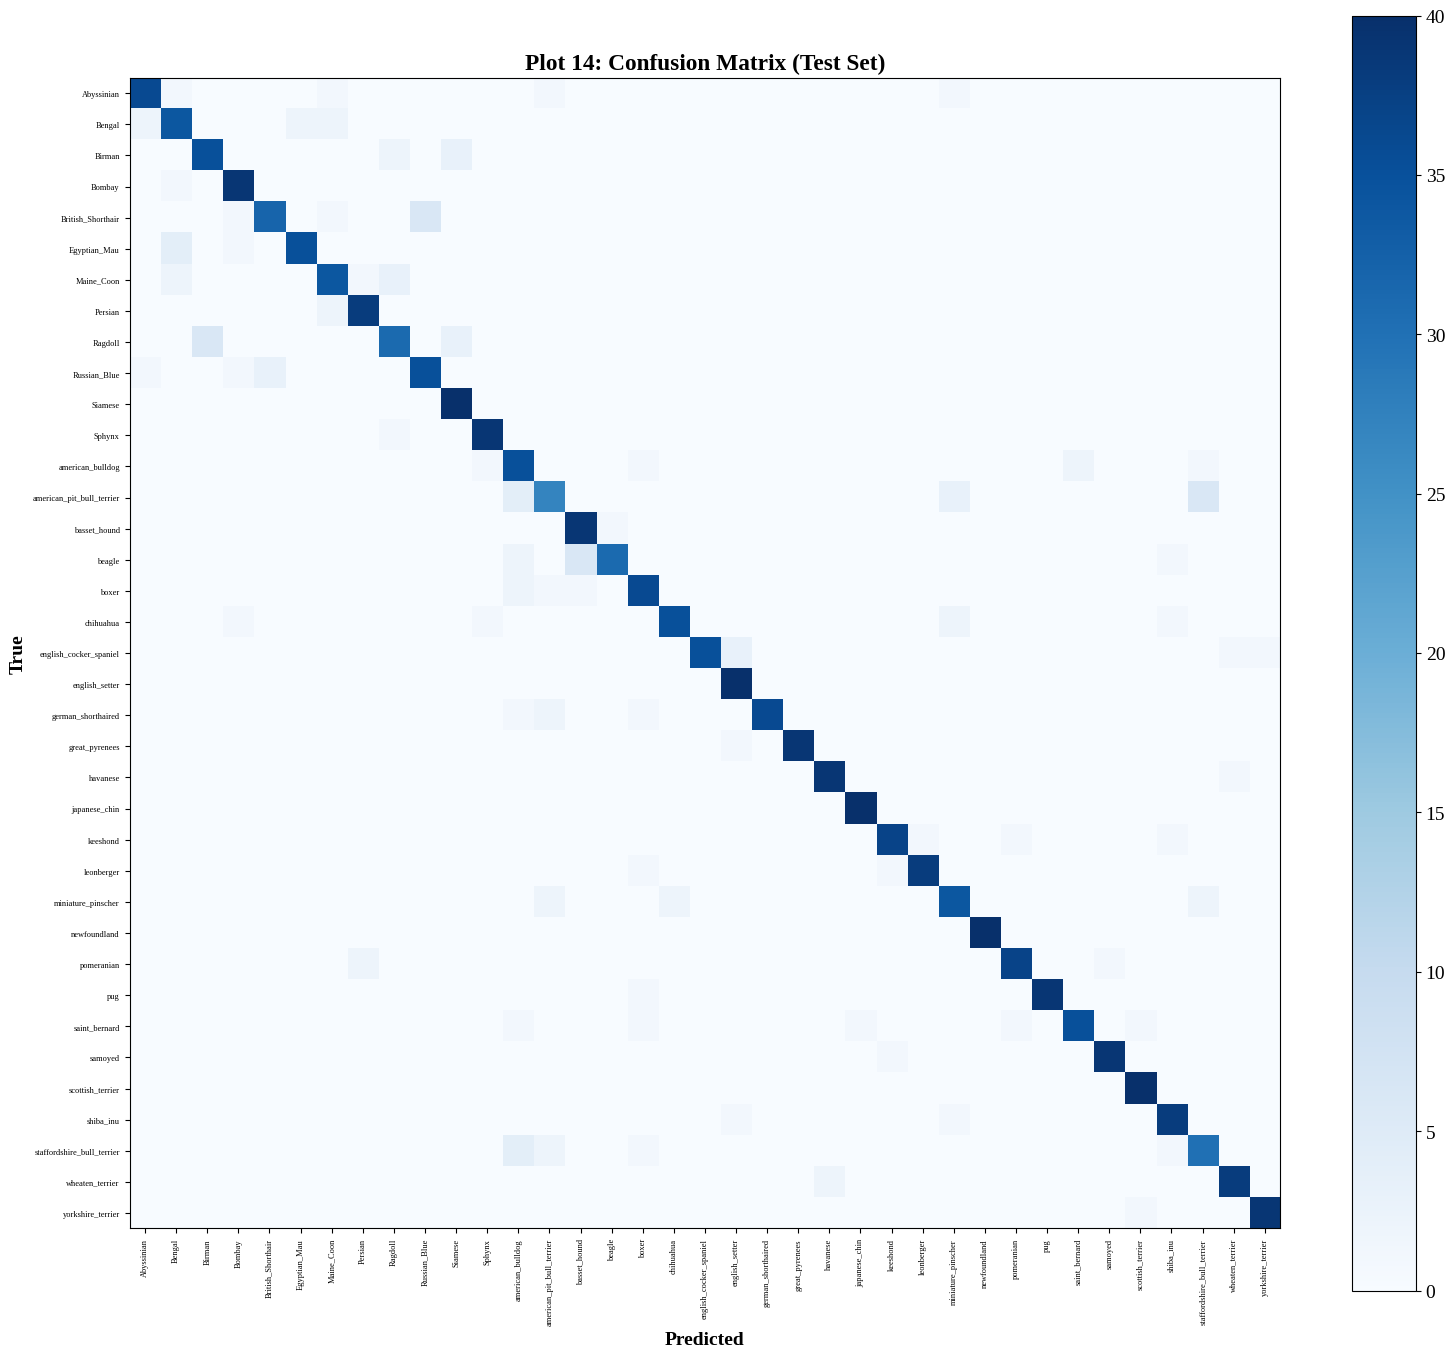

Best classified classes:
 scottish_terrier    1.0
japanese_chin       1.0
newfoundland        1.0
english_setter      1.0
Siamese             1.0
dtype: float64

Most frequently confused (worst) classes:
 British_Shorthair             0.800000
staffordshire_bull_terrier    0.789474
Ragdoll                       0.775000
beagle                        0.775000
american_pit_bull_terrier     0.675000
dtype: float64


In [41]:
class_names_sorted = [idx_to_breed[i] for i in range(NUM_CLASSES)]
cm = plot_confusion(y_true, y_pred, class_names_sorted, title="Plot 14: Confusion Matrix (Test Set)",
                     save_name="plot14_confusion_matrix")

per_class_acc = cm.diagonal() / cm.sum(axis=1)
acc_series = pd.Series(per_class_acc, index=class_names_sorted).sort_values(ascending=False)
print("Best classified classes:\n", acc_series.head(5))
print("\nMost frequently confused (worst) classes:\n", acc_series.tail(5))


Saved: /kaggle/working/figures/plot15_misclassified.png


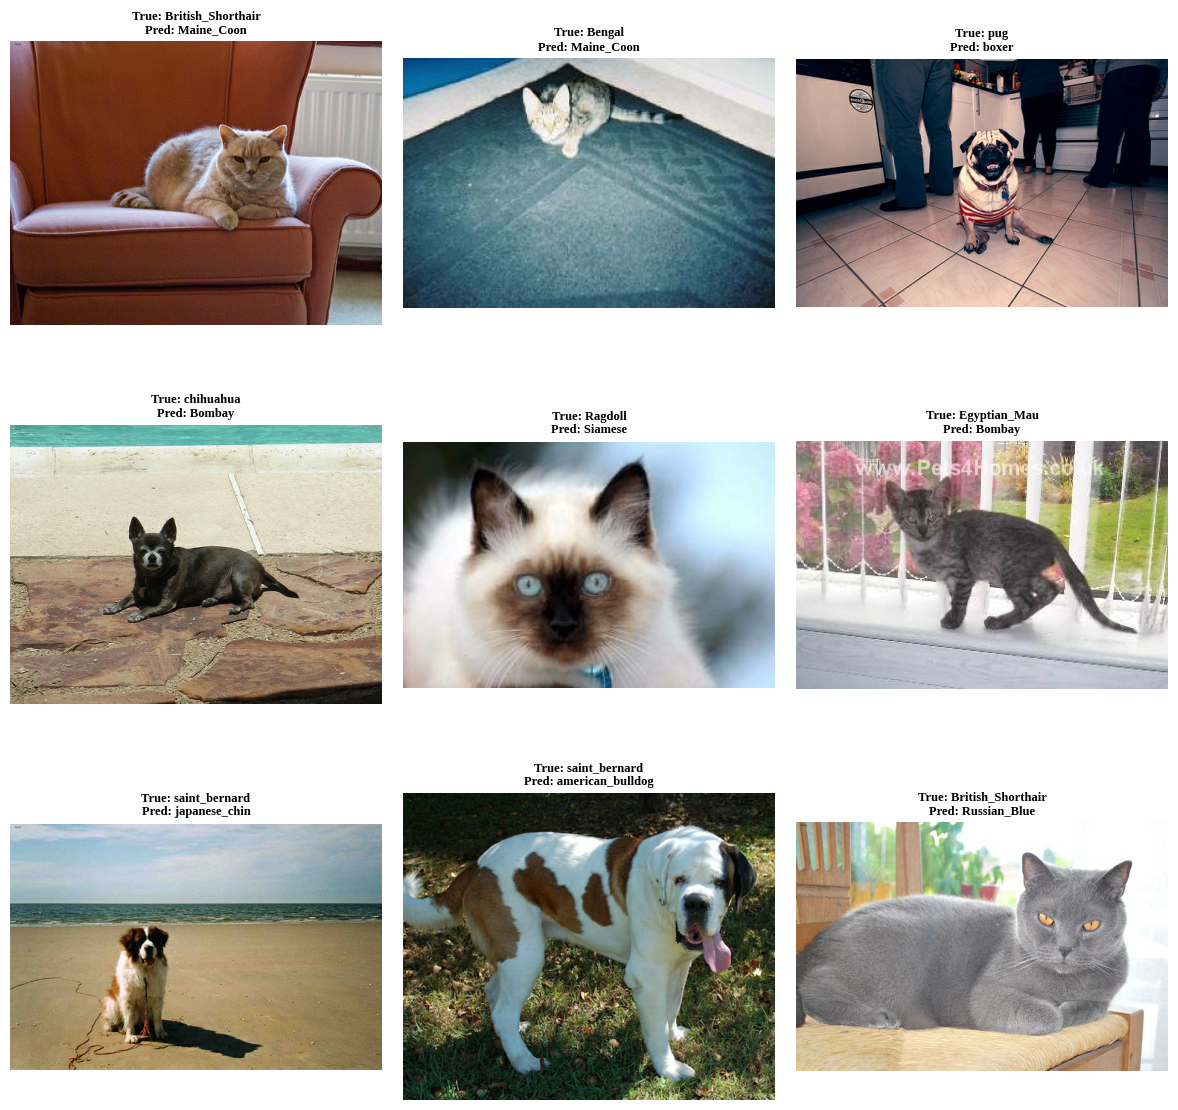

In [42]:
# Optional Plot 15: representative misclassified images
mis_idx = np.where(y_true != y_pred)[0]
n_show = min(9, len(mis_idx))
if n_show > 0:
    sample_mis = np.random.choice(mis_idx, size=n_show, replace=False)
    test_paths = test_df["path"].values  # order matches final_test_ds since shuffle=False

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for ax, idx in zip(axes.flatten(), sample_mis):
        img = tf.io.decode_jpeg(tf.io.read_file(test_paths[idx]), channels=3)
        ax.imshow(img)
        ax.set_title(f"True: {class_names_sorted[y_true[idx]]}\nPred: {class_names_sorted[y_pred[idx]]}", fontsize=9)
        ax.axis("off")
    for ax in axes.flatten()[n_show:]:
        ax.axis("off")
    plt.tight_layout()
    save_fig(fig, "plot15_misclassified")
    plt.show()
else:
    print("No misclassified test images to display.")


## 10. Section 13 — Overall Results Summary

Pulled automatically from `results_store` / `cv_results` -- nothing re-entered by hand.

In [43]:
overall_rows = [
    {"Configuration": f"Best Initialization ({best_init})", "CV Accuracy": np.nan, "SD": np.nan,
     "Test Accuracy": np.nan, "Training Time (s)": results_store[init_runs[best_init]]["train_time_sec"]},
    {"Configuration": f"Best Regularization ({best_reg})", "CV Accuracy": np.nan, "SD": np.nan,
     "Test Accuracy": np.nan, "Training Time (s)": results_store[reg_runs[best_reg]]["train_time_sec"]},
    {"Configuration": f"Best Optimizer ({best_optimizer})", "CV Accuracy": np.nan, "SD": np.nan,
     "Test Accuracy": np.nan, "Training Time (s)": results_store[opt_runs[best_optimizer]]["train_time_sec"]},
    {"Configuration": f"Best Hyperparameters ({best_config_name})",
     "CV Accuracy": cv_results[best_config_name]["mean"], "SD": cv_results[best_config_name]["std"],
     "Test Accuracy": np.nan, "Training Time (s)": np.nan},
    {"Configuration": "Fine-Tuned / Final Model",
     "CV Accuracy": cv_results[best_config_name]["mean"], "SD": cv_results[best_config_name]["std"],
     "Test Accuracy": test_acc, "Training Time (s)": results_store["final_model"]["train_time_sec"]},
]
overall_table = pd.DataFrame(overall_rows)
overall_table


,Configuration,CV Accuracy,SD,Test Accuracy,Training Time (s)
0,Best Initialization (random),NaN,NaN,NaN,228.050194
1,Best Regularization (batchnorm),NaN,NaN,NaN,227.811126
2,Best Optimizer (adam),NaN,NaN,NaN,227.247014
3,Best Hyperparameters (C2),0.911351,0.003738,NaN,NaN
4,Fine-Tuned / Final Model,0.911351,0.003738,0.909337,155.142726


## 12. Section 16 — Additional Exercise

Two new configurations (from the unused portion of the search space) are evaluated with the same 5-fold CV function and compared against the originally selected configuration.

In [44]:
remaining_combos = [c for c in all_combos if c not in sampled_combos]
extra_combos = random.sample(remaining_combos, k=2)
extra_configs = [{"lr": lr, "dropout_rate": dr, "unfreeze_from": uf} for lr, dr, uf in extra_combos]

extra_cv_results = {}
for i, cfg in enumerate(extra_configs, 1):
    run_prefix = f"cv_Extra{i}"
    print(f"Running 5-fold CV for Extra{i}: {cfg}")
    fold_accs, mean_acc, std_acc = run_kfold_cv(cfg, run_prefix)
    extra_cv_results[f"Extra{i}"] = {"config": cfg, "fold_accs": fold_accs, "mean": mean_acc, "std": std_acc}
    print(f"Extra{i}: {mean_acc:.4f} +/- {std_acc:.4f}\n")


Running 5-fold CV for Extra1: {'lr': 0.0001, 'dropout_rate': 0.0, 'unfreeze_from': None}


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Logged run 'cv_Extra1_fold1'. Best val_accuracy so far: 0.8960
  cv_Extra1_fold1: val_acc = 0.8960


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Logged run 'cv_Extra1_fold2'. Best val_accuracy so far: 0.8909
  cv_Extra1_fold2: val_acc = 0.8909


...

Logged run 'cv_Extra2_fold3'. Best val_accuracy so far: 0.3739
  cv_Extra2_fold3: val_acc = 0.1802


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Logged run 'cv_Extra2_fold4'. Best val_accuracy so far: 0.3621
  cv_Extra2_fold4: val_acc = 0.2090


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Logged run 'cv_Extra2_fold5'. Best val_accuracy so far: 0.3519
  cv_Extra2_fold5: val_acc = 0.1954
Extra2: 0.2519 +/- 0.0705



In [45]:
combined = {**cv_results, **extra_cv_results}
comp_table = pd.DataFrame([
    {"Configuration": k, "Mean Accuracy": v["mean"], "SD": v["std"], "Config": v["config"]}
    for k, v in combined.items()
]).sort_values("Mean Accuracy", ascending=False).reset_index(drop=True)

print(f"Originally selected configuration: {best_config_name} "
      f"({cv_results[best_config_name]['mean']:.4f} +/- {cv_results[best_config_name]['std']:.4f})")
new_best = comp_table.iloc[0]
print(f"Overall best across original + extra configurations: {new_best['Configuration']} "
      f"({new_best['Mean Accuracy']:.4f} +/- {new_best['SD']:.4f})")
comp_table


Originally selected configuration: C2 (0.9114 +/- 0.0037)
Overall best across original + extra configurations: C2 (0.9114 +/- 0.0037)


,Configuration,Mean Accuracy,SD,Config
0,C2,0.911351,0.003738,"{'lr': 0.001, 'dropout_rate': 0.25, 'unfreeze_..."
1,C3,0.910843,0.004758,"{'lr': 0.001, 'dropout_rate': 0.0, 'unfreeze_f..."
2,Extra1,0.892234,0.006444,"{'lr': 0.0001, 'dropout_rate': 0.0, 'unfreeze_..."
3,C1,0.805619,0.013703,"{'lr': 1e-05, 'dropout_rate': 0.0, 'unfreeze_f..."
4,C4,0.755711,0.011061,"{'lr': 1e-05, 'dropout_rate': 0.25, 'unfreeze_..."
5,Extra2,0.251890,0.070482,"{'lr': 0.001, 'dropout_rate': 0.25, 'unfreeze_..."
